<a href="https://colab.research.google.com/github/rishitachoudhury7/-linear-vs-polynomial-regression-/blob/main/Canada_CapitaIncome_LinearReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
from sklearn import linear_model
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('canada_per_capita_income.csv')
df.head(3)

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484


Text(0, 0.5, 'per capita income (US$)')

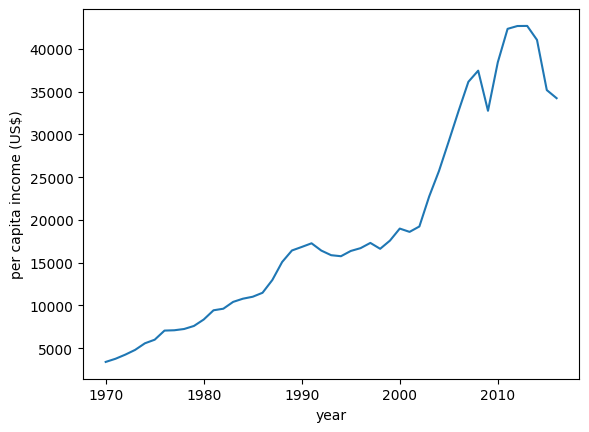

In [29]:
%matplotlib inline
plt.plot(df.year, df['per capita income (US$)'])
plt.xlabel('year')
plt.ylabel('per capita income (US$)')


Now we will make a new dataframe to separate the  2 variables. i,e Dependent and Independent variable
We'll always drop the Y axis/dependent variable

In [30]:
new_df = df.drop('per capita income (US$)', axis='columns')
new_df.head(3)

,year
0,1970
1,1971
2,1972


In [31]:
per_capita_income = df['per capita income (US$)']
per_capita_income.head(3)

,per capita income (US$)
0,3399.299037
1,3768.297935
2,4251.175484


In [32]:
#Now create a linear regression func called reg

In [33]:
reg = linear_model.LinearRegression()
reg.fit(new_df, per_capita_income)

LinearRegression()

fit()- we are telling our model to look over all the given datapints and find a pattern b/w input and output/ dependent and independent variables.

Mathematically fit() tried to find the best value for m and b.

In [34]:
reg.coef_

array([828.46507522])

In [35]:
reg.intercept_

np.float64(-1632210.7578554575)

The slope (828.47) means:

On average, income increases by about $828 per year

The intercept is negative because:

The model is extrapolating back to year 0 (which isn’t meaningful in real life)

Now we will find the per_capita_income of Canada in 2020

In [36]:
reg.predict(pd.DataFrame([[2020]], columns=['year']))

array([41288.69409442])

In [37]:
828.46507522*2020-1632210.7578554575

41288.694088942604

Now we will find the per_capita_income of Canada in 2026

In [38]:
reg.predict(pd.DataFrame([[2026]], columns = ['year']))

array([46259.48454575])

In [39]:
828.46507522*2026-1632210.7578554575

46259.48454026249

model is correct mathematically, this dataset is not perfectly linear


A better model might be:

Polynomial regression (degree 2 or 3)
Or exponential growth model

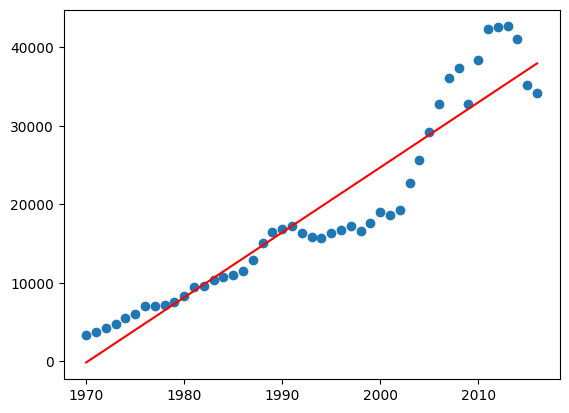

In [40]:
%matplotlib inline
plt.scatter(df.year, df['per capita income (US$)'])
plt.plot(df.year, reg.predict(df[['year']]), color='red')

In [41]:
pred_income = reg.predict(new_df)

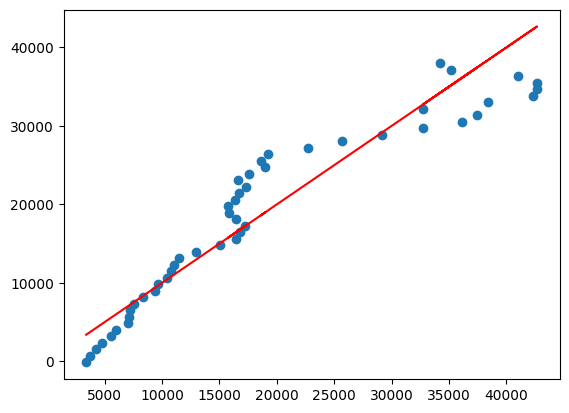

In [42]:
plt.scatter(df['per capita income (US$)'], pred_income)
plt.plot(per_capita_income, per_capita_income, color='red')

In [43]:
reg.score(new_df, per_capita_income)  #R^2 = coefficient of determinatio

0.890916917957032

The coefficient of determination (R²) for the model is 0.8909, meaning that 89.09% of the variability in per capita income can be explained by the year. This indicates a strong positive relationship between year and income. However, the remaining ~11% unexplained variance suggests that the data may not be perfectly linear, and a more complex model (e.g., polynomial regression) could improve performance.

In [44]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(per_capita_income, pred_income)
print("MSE:", mse)

MSE: 15462739.061504772


The Mean Squared Error (MSE) of the model is 15,462,739, which represents the average of the squared differences between actual and predicted income values. A lower MSE indicates better model performance; however, since the values are squared, the error appears large and is less interpretable.

In [45]:
import numpy as np

rmse = np.sqrt(15462739.061504772)   #Root Mean Squared Error (RMSE)
print(rmse)

3932.268945723928


The Root Mean Squared Error (RMSE) is approximately 3932, meaning that the model’s predictions deviate from actual values by about $3932 on average.

The model achieved an R² score of 0.89, indicating a strong fit. The RMSE value of approximately 3932 suggests that the model's predictions are reasonably accurate, although some error remains due to non-linear trends in the data.